# Scalar finite-section error bounds

## Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import lambertw
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply

D0 = 1.0
R = 1.0
mu0 = 1.0
time_points = 2001

positive_initial = 0.1
positive_orders = np.arange(1, 41)
positive_time_fraction = 0.5

negative_initial = 0.2
negative_orders = np.arange(1, 26)
negative_horizons = [1.0, 10.0, 50.0]

## Model and Simulation Functions

For the positive scalar system, Theorem 3.1 gives

$$
\left|y_{1,N}(t)-x(t)\right|
\leq
\frac{RM_0}{\sqrt{2\pi}(R-M_0)}
N^{-3/2}
\exp\!\left(\frac{D_0(t-t_0)N}{R}\right)
\left(\frac{ex_0}{R}\right)^{\frac{(e-1)N}{2e-1}},
$$

where

$$
M_0=x_0^{\frac{e-1}{2e-1}}
\left(\frac{R}{e}\right)^{\frac{e}{2e-1}},
\qquad
T^*=\frac{(e-1)R}{(2e-1)D_0}
\ln\!\left(\frac{R}{ex_0}\right).
$$

For the stable negative system, Theorem 3.4 gives

$$
\left|y_{1,N}(t)-x(t)\right|
\leq
x_0\left(
\frac{(D_0+R\mu_0)x_0}{R^2\mu_0}
\right)^N.
$$

With $D_0=R=\mu_0=1$,

$$
\left|y_{1,N}(t)-x(t)\right|\leq x_0(2x_0)^N.
$$

In [2]:
def exact_solution(times, initial, sign):
    argument = initial**2 * np.exp(initial**2 + 2.0 * sign * times)
    return np.sqrt(lambertw(argument).real)


def carleman_matrix(order, sign):
    rows = []
    columns = []
    values = []

    for k in range(1, order + 1):
        for ell in range(k, order + 1, 2):
            rows.append(k - 1)
            columns.append(ell - 1)
            values.append(sign * k * (-1) ** ((ell - k) // 2))

    return csr_matrix(
        (values, (rows, columns)),
        shape=(order, order),
        dtype=float,
    )


def all_order_maximum_errors(initial, max_order, sign, final_time):
    matrix = carleman_matrix(max_order, sign)
    basis = np.zeros(max_order)
    basis[0] = 1.0
    trace = float(matrix.diagonal().sum())

    if final_time <= 2.0:
        times = np.linspace(0.0, final_time, time_points)
        coefficients = expm_multiply(
            matrix.T,
            basis,
            start=0.0,
            stop=final_time,
            num=times.size,
            endpoint=True,
            traceA=trace,
        )
    else:
        dense_times = np.linspace(0.0, 2.0, 1201)
        dense_coefficients = expm_multiply(
            matrix.T,
            basis,
            start=0.0,
            stop=2.0,
            num=dense_times.size,
            endpoint=True,
            traceA=trace,
        )
        tail_times = np.geomspace(2.0, final_time, 81)[1:]
        tail_coefficients = np.vstack([
            expm_multiply(matrix.T * time, basis, traceA=trace * time)
            for time in tail_times
        ])
        times = np.concatenate((dense_times, tail_times))
        coefficients = np.vstack((dense_coefficients, tail_coefficients))

    exact = exact_solution(times, initial, sign)
    approximation = np.zeros(times.size)
    errors = np.empty(max_order)

    for order_index in range(max_order):
        approximation += coefficients[:, order_index] * initial ** (order_index + 1)
        errors[order_index] = np.max(np.abs(approximation - exact))

    return errors


def theorem_31_time_limit(initial):
    return (
        (np.e - 1.0) * R
        / ((2.0 * np.e - 1.0) * D0)
        * np.log(R / (np.e * initial))
    )


def theorem_31_bound(initial, order, time):
    exponent = (np.e - 1.0) / (2.0 * np.e - 1.0)
    M0 = initial**exponent * (R / np.e) ** (
        np.e / (2.0 * np.e - 1.0)
    )

    return (
        R * M0
        / (np.sqrt(2.0 * np.pi) * (R - M0))
        * order ** (-1.5)
        * np.exp(D0 * time * order / R)
        * (initial * np.e / R) ** (exponent * order)
    )


def theorem_34_bound(initial, order):
    return initial * (
        (D0 + R * mu0) * initial / (R**2 * mu0)
    ) ** order

## Simulation

In [3]:
positive_time_limit = theorem_31_time_limit(positive_initial)
positive_time = positive_time_fraction * positive_time_limit
positive_errors = all_order_maximum_errors(
    positive_initial,
    positive_orders[-1],
    1,
    positive_time,
)
positive_bounds = np.array([
    theorem_31_bound(positive_initial, order, positive_time)
    for order in positive_orders
])

negative_errors = {
    horizon: all_order_maximum_errors(
        negative_initial,
        negative_orders[-1],
        -1,
        horizon,
    )
    for horizon in negative_horizons
}
negative_bounds = np.array([
    theorem_34_bound(negative_initial, order)
    for order in negative_orders
])

positive_violations = np.count_nonzero(positive_errors > positive_bounds + 1e-13)
negative_violations = {
    horizon: np.count_nonzero(errors > negative_bounds + 1e-13)
    for horizon, errors in negative_errors.items()
}

check_times_positive = np.linspace(0.0, positive_time, 401)
check_times_negative = np.linspace(0.0, max(negative_horizons), 401)

positive_numerical = solve_ivp(
    lambda _, state: state / (1.0 + state**2),
    (0.0, positive_time),
    [positive_initial],
    t_eval=check_times_positive,
    rtol=1e-12,
    atol=1e-14,
).y[0]

negative_numerical = solve_ivp(
    lambda _, state: -state / (1.0 + state**2),
    (0.0, max(negative_horizons)),
    [negative_initial],
    t_eval=check_times_negative,
    rtol=1e-12,
    atol=1e-14,
).y[0]

positive_exact_check = np.max(
    np.abs(positive_numerical - exact_solution(check_times_positive, positive_initial, 1))
)
negative_exact_check = np.max(
    np.abs(negative_numerical - exact_solution(check_times_negative, negative_initial, -1))
)

## Results

Positive exact solution check: 3.256e-14
Negative exact solution check: 3.891e-14
Theorem 3.1 bound violations:  0
Theorem 3.4 violations, T=1: 0
Theorem 3.4 violations, T=10: 0
Theorem 3.4 violations, T=50: 0


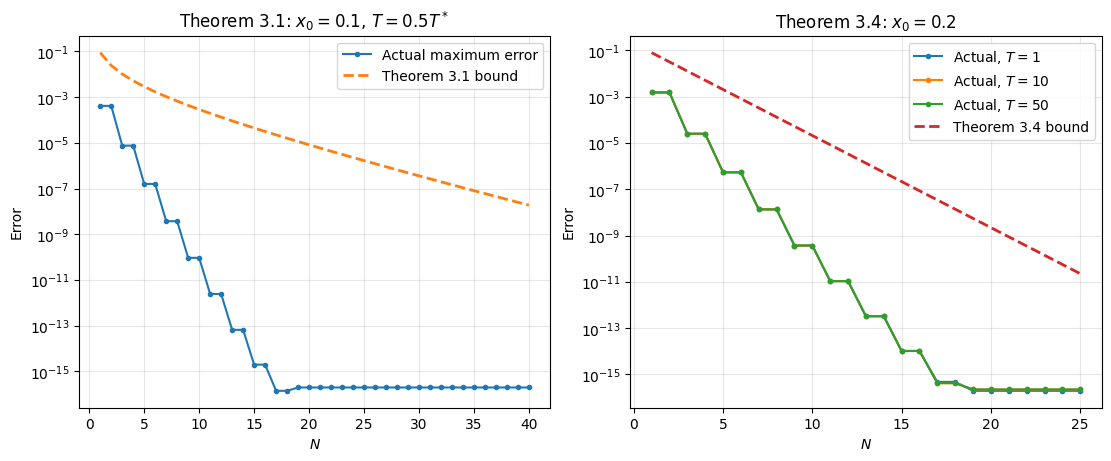

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.5), constrained_layout=True)

axes[0].semilogy(
    positive_orders,
    np.maximum(positive_errors, 1e-16),
    "o-",
    markersize=3,
    label="Actual maximum error",
)
axes[0].semilogy(
    positive_orders,
    positive_bounds,
    "--",
    linewidth=2,
    label="Theorem 3.1 bound",
)
axes[0].set_xlabel(r"$N$")
axes[0].set_ylabel("Error")
axes[0].set_title(
    rf"Theorem 3.1: $x_0={positive_initial}$, "
    rf"$T={positive_time_fraction}T^*$"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for horizon in negative_horizons:
    axes[1].semilogy(
        negative_orders,
        np.maximum(negative_errors[horizon], 1e-16),
        "o-",
        markersize=3,
        label=rf"Actual, $T={horizon:g}$",
    )

axes[1].semilogy(
    negative_orders,
    negative_bounds,
    "--",
    linewidth=2,
    label="Theorem 3.4 bound",
)
axes[1].set_xlabel(r"$N$")
axes[1].set_ylabel("Error")
axes[1].set_title(rf"Theorem 3.4: $x_0={negative_initial}$")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

print(f"Positive exact solution check: {positive_exact_check:.3e}")
print(f"Negative exact solution check: {negative_exact_check:.3e}")
print(f"Theorem 3.1 bound violations:  {positive_violations}")

for horizon in negative_horizons:
    print(f"Theorem 3.4 violations, T={horizon:g}: {negative_violations[horizon]}")